# 01 — Exploratory Data Analysis: Bank Transactions

This notebook explores the [Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection) (Kaggle, V. Khorasani).

**Goal:** Understand the structure of the data, profile key variables, and identify candidate signals for anomaly/fraud detection before any modeling is attempted.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/bank_transactions_data_2.csv')
df.shape

(2512, 16)

## 1. Structure and data quality

We start by profiling column types and checking for missing values, then classify each column by its *role* (identifier, numeric feature, categorical feature, behavioral signal) since this determines what is usable as a model input later.


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

In [3]:
df.isnull().sum().sum()  # total missing cells

np.int64(0)

In [4]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TransactionID,2512,2512,TX000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,2512,495,AC00202,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmount,2512.0,NaN,NaN,NaN,297.593778,0.26,81.885,211.14,414.5275,1919.11,291.946243
TransactionDate,2512,NaN,NaN,NaN,2023-07-05 20:32:10.826433,2023-01-02 16:00:06,2023-04-03 16:22:05.750000,2023-07-07 17:49:43.500000,2023-10-06 18:40:53.500000,2024-01-01 18:21:50,NaN
TransactionType,2512,2,Debit,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2512,43,Fort Worth,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceID,2512,681,D000142,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP Address,2512,592,200.136.146.93,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MerchantID,2512,100,M026,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2512,3,Branch,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Distributions

Looking at the shape of the core numeric variables: transaction amount, customer age, transaction duration, and login attempts.


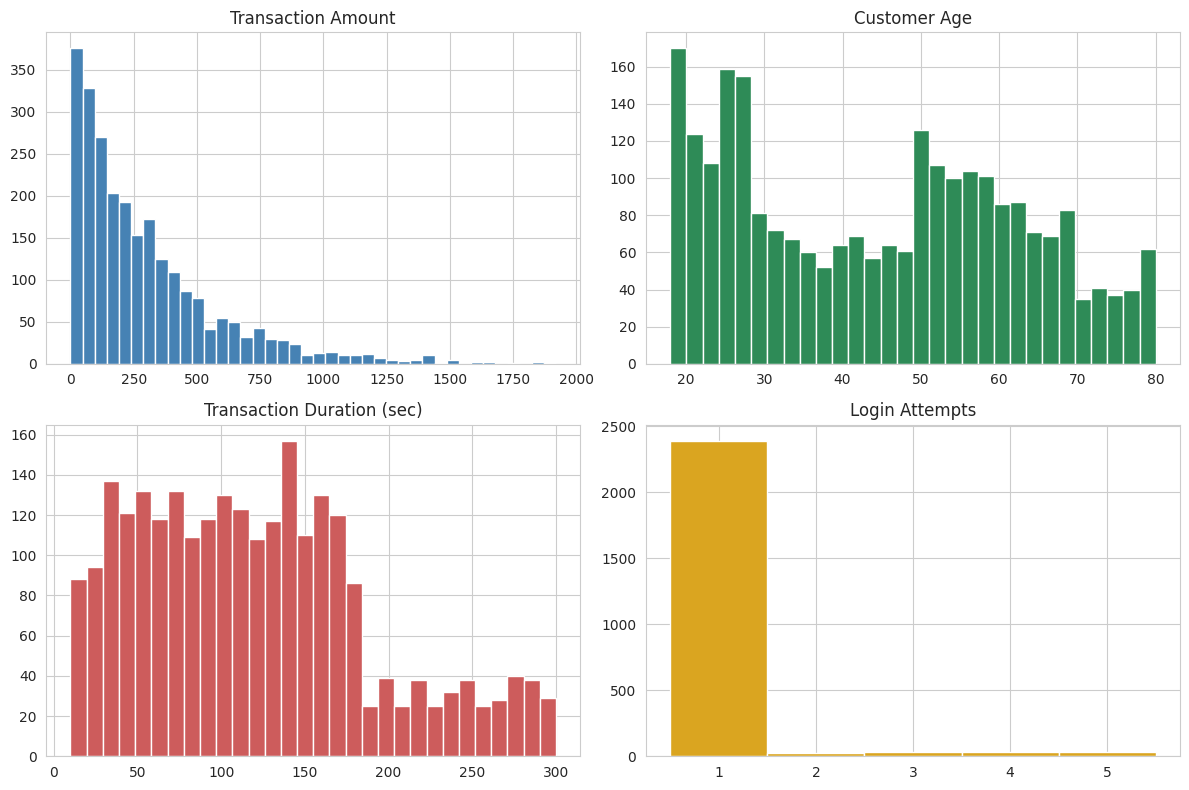

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['TransactionAmount'], bins=40, color='steelblue')
axes[0,0].set_title('Transaction Amount')

axes[0,1].hist(df['CustomerAge'], bins=30, color='seagreen')
axes[0,1].set_title('Customer Age')

axes[1,0].hist(df['TransactionDuration'], bins=30, color='indianred')
axes[1,0].set_title('Transaction Duration (sec)')

axes[1,1].hist(df['LoginAttempts'], bins=range(1,7), color='goldenrod', align='left')
axes[1,1].set_title('Login Attempts')

plt.tight_layout()
plt.show()

**Observation:** `LoginAttempts` is heavily skewed — the vast majority of transactions involve exactly 1 login attempt, with a small tail of 2–5 attempts. This asymmetry makes it a candidate behavioral signal: transactions requiring multiple login attempts are, by definition, rare and worth flagging as unusual.


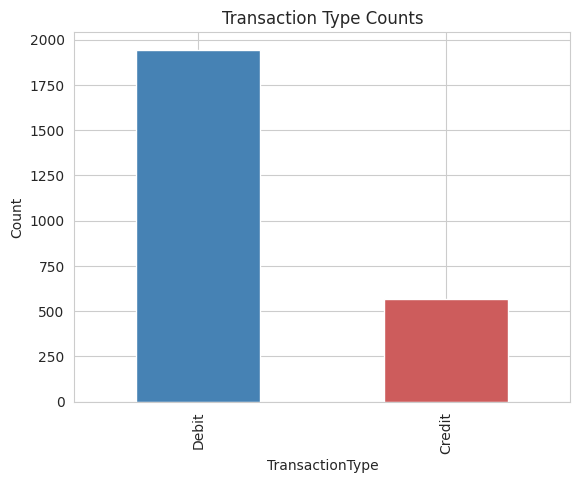

In [6]:
df['TransactionType'].value_counts().plot(kind='bar', color=['steelblue','indianred'])
plt.title('Transaction Type Counts')
plt.ylabel('Count')
plt.show()

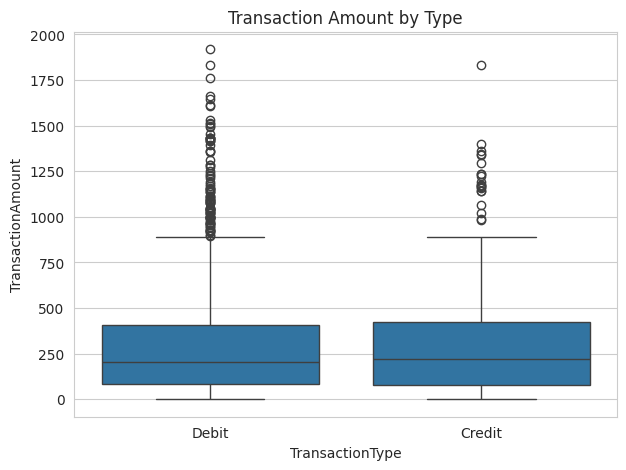

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.title('Transaction Amount by Type')
plt.show()

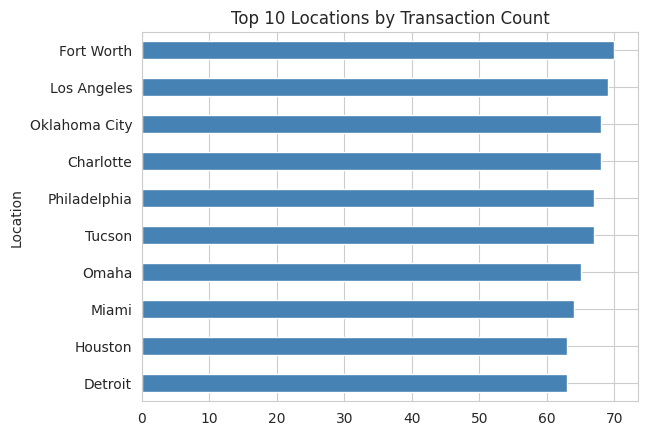

In [8]:
df['Location'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Locations by Transaction Count')
plt.gca().invert_yaxis()
plt.show()

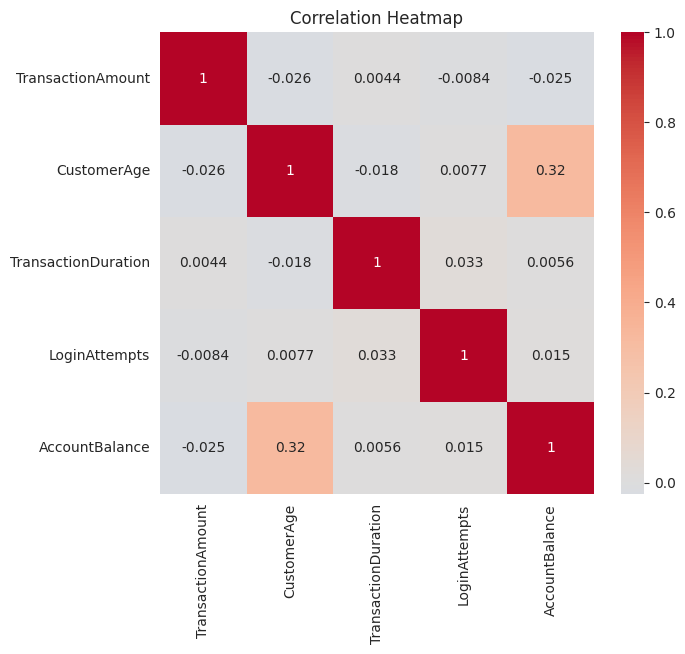

In [9]:
numeric_cols = ['TransactionAmount','CustomerAge','TransactionDuration','LoginAttempts','AccountBalance']
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## 3. A data quality caveat: `AccountBalance`

Before using `AccountBalance` as a feature (e.g. to compute a "transaction amount relative to balance" ratio), it's worth checking whether the column behaves as a coherent running balance across a customer's transaction history.

We trace a single account's transactions in chronological order:


In [10]:
counts = df['AccountID'].value_counts()
sample_acc = counts[counts.between(6,8)].index[0]

trace = df[df['AccountID']==sample_acc].sort_values('TransactionDate')
trace[['TransactionDate','TransactionType','TransactionAmount','AccountBalance']]

,TransactionDate,TransactionType,TransactionAmount,AccountBalance
2480,2023-03-30 16:52:05,Credit,99.98,3037.97
1296,2023-04-07 17:11:35,Debit,93.22,1014.63
1931,2023-04-25 16:23:59,Debit,31.19,5545.96
3,2023-05-05 16:32:11,Debit,184.50,8569.06
1254,2023-06-15 18:28:50,Debit,142.19,524.46
218,2023-07-07 18:03:43,Credit,890.24,5140.93
1003,2023-09-18 16:03:10,Debit,156.58,8981.61
442,2023-11-13 17:34:15,Debit,293.97,7371.85


**Finding:** the balance does not move consistently with the transaction amounts (e.g. a small debit is sometimes followed by a large *increase* in balance with no corresponding credit transaction). This indicates `AccountBalance` is not a reliable pre/post-transaction running balance in this synthetic dataset — likely an independently generated snapshot value per row.

**Decision:** we exclude `AccountBalance`-derived ratios from the anomaly-detection features in this project and document this as a known data limitation, rather than silently trusting a feature that doesn't hold up under inspection. `TransactionAmount` and `LoginAttempts` are used instead, since both show clean, interpretable distributions.


## Summary

- 2,512 transactions, no missing values.
- `LoginAttempts` and `TransactionAmount` are the two cleanest, most interpretable candidate signals for anomaly detection.
- `AccountBalance` has an internal consistency problem and is excluded from downstream feature engineering.

Next: `02_anomaly_detection.ipynb` — rule-based flagging, K-Means, and DBSCAN.
